# Surrogate/oracle **peak** design — curated dataset, **CNN-only**

The *peak_design* analog of `../design/surrogate_model_design_dual.ipynb`. Every model regresses the **two peak
wavelengths** `(ex_max, em_max)` (nm). Trained on the **curated** dataset (758 samples — cofactor ∪ NN-4mer<0.10
∪ frFAST/nirFAST removed; see `curate_split_visualize.ipynb`).

Two coordinated splits pick a **surrogate** (dataset 1) and an **oracle** (dataset 2): val sets disjoint,
`S_test ⊆ O_train`, `O_test ⊆ S_train`; per-sample dual labels saved for in-sample/OOD design eval.

Backbones: **CNN only**, with a `mean / min / max / concat` masked-pooling readout over ESM-2 per-residue
embeddings (4 readout options defined). Targets are standardized on each dataset's train split; training minimizes
standardized-peak MSE; early-stopping uses **validation peak MAE (nm)**. We train a **single fixed readout per
dataset** — **surrogate = cnn-max**, **oracle = cnn-concat** (no readout search). Both are CNNs, so the oracle's
independence comes from its **disjoint training split**, not a different architecture.

## 0. Setup + data + per-residue embeddings

In [1]:
import csv, os, numpy as np, torch, torch.nn as nn, hashlib, time
import peak_models as pm
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception:
    HAVE_APC=False
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
except Exception:
    HAVE_PLT=False
class _C:  # arcadia-pycolor colors with graceful fallback
    def __getattr__(self, k): return getattr(apc, k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888888","wish":"#5088c5","aster":"#7a5ea8"}.get(k,"#333333")
apc_c=_C()

TD="training_data"; CUR=os.path.join(TD,"curated")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

# CURATED peak dataset (outliers removed in curate_split_visualize.ipynb)
rows=list(csv.DictReader(open(os.path.join(CUR,"peak_assignments.csv")))); N=len(rows)
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32)       # (N,2) = [ex_max, em_max] nm
EXM=peaks[:,0]; EMM=peaks[:,1]
keep=np.load(os.path.join(CUR,"keep_index.npy"))                      # curated -> raw row map
seqs=[None]*N; h=None
for line in open(os.path.join(CUR,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
assert all(s is not None for s in seqs), "missing sequences"

# per-residue ESM-2 embeddings: subset the raw 894-sample cache by keep_index (no re-embedding)
RP=os.path.join(TD,"esm_residue_fp16.npy"); LP=os.path.join(TD,"esm_residue_len.npy")
assert os.path.exists(RP), "raw embedding cache missing — build it once via build_peak_dataset.py + the raw dual run / curate notebook"
H=np.load(RP)[keep]; Ls=np.load(LP)[keep]
Lmax=int(Ls.max()); H=H[:,:Lmax]                                     # trim padding cols to curated max length
Ht=torch.tensor(H); ar=torch.arange(Lmax); os.makedirs("trained_models",exist_ok=True)
def batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),b
print("device",dev,"| N",N,"| ex_max",f"{EXM.min():.0f}-{EXM.max():.0f}","| em_max",f"{EMM.min():.0f}-{EMM.max():.0f}")

device mps | N 758 | ex_max 343-690 | em_max 414-711


## 1. Load the coordinated dual split

The surrogate/oracle split is defined, visualized (bipartite map), and written by
`curate_split_visualize.ipynb` → `curated/dual_splits.csv`. We **load** it here rather than recompute it:
the logic/seed are identical, so recomputing was byte-for-byte redundant. Loading keeps a single source of
truth and guarantees this notebook trains on exactly the split shown in the curation report.

In [2]:
# Split is owned by curate_split_visualize.ipynb; load curated/dual_splits.csv (do NOT recompute).
ds=sorted(csv.DictReader(open(os.path.join(CUR,"dual_splits.csv"))), key=lambda r:int(r["index"]))
assert len(ds)==N, f"dual_splits.csv has {len(ds)} rows but curated N={N} — re-run curate_split_visualize.ipynb"
Srole=np.array([r["surrogate_role"] for r in ds])
Orole=np.array([r["oracle_role"]   for r in ds])
# sanity-check the dual-split invariants on the loaded split
assert np.all(Orole[Srole=="test"]=="train") and np.all(Srole[Orole=="test"]=="train")
assert np.sum((Srole=="val")&(Orole=="val"))==0
def cnt(a): return {b:int((a==b).sum()) for b in("train","val","test")}
print("loaded curated/dual_splits.csv | surrogate (S):", cnt(Srole), "| oracle (O):", cnt(Orole))
SIDX={b:np.where(Srole==b)[0] for b in("train","val","test")}
OIDX={b:np.where(Orole==b)[0] for b in("train","val","test")}

loaded curated/dual_splits.csv | surrogate (S): {'train': 530, 'val': 114, 'test': 114} | oracle (O): {'train': 530, 'val': 114, 'test': 114}


## 2. Models (CNN × {mean,min,max,concat}) + train/eval + cache

Each base net predicts **standardized** `(ex_max, em_max)`; a `StandardizedPeaks` wrapper bakes the
inverse-standardization back into the model so `forward()` returns peaks in **nm**. Only the base net is saved;
the per-dataset train-split `(mean, std)` is re-attached on load (`load_wrapped`). Training minimizes
standardized-peak MSE; model selection / early-stopping use validation **peak MAE (nm)**.

In [3]:
DROP=0.2; LR=1e-3; WD=1e-4; EP_CNN=150; EP_TF=150; FORCE=False
MODELS=[]
for pool in pm.POOLS: MODELS.append(dict(arch="cnn", pool=pool, conv_ch=128, k=5, hidden=256, nl=2, sid=f"cnn-{pool}"))

def standardizer(idx):                                          # (mean, std) of peaks over train idx
    m=peaks[idx].mean(0); s=peaks[idx].std(0)+1e-6; return m.astype(np.float32), s.astype(np.float32)
def wrapw(base, mean, std): return pm.wrap(base, mean, std, dev)
def load_wrapped(path, mean, std): base,ck=pm.load_model(path,dev); return wrapw(base,mean,std), ck

Pk=torch.tensor(peaks, dtype=torch.float32, device=dev)         # (N,2) nm targets
def predict_peaks(net, idx):                                    # wrapped net -> (n,2) nm
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in batches(idx): ps.append(net(Hb,mk).cpu().numpy())
    return np.concatenate(ps)
def _r2(t,p):
    t=np.asarray(t,float); p=np.asarray(p,float); ss=((t-t.mean())**2).sum()
    return 1-((t-p)**2).sum()/ss if ss>0 else float("nan")
def evaluate(net, idx):
    P=predict_peaks(net, idx); T=peaks[idx]
    ex_mae=float(np.abs(P[:,0]-T[:,0]).mean()); em_mae=float(np.abs(P[:,1]-T[:,1]).mean())
    return dict(mae=0.5*(ex_mae+em_mae), ex_mae=ex_mae, em_mae=em_mae,
                r2_ex=_r2(T[:,0],P[:,0]), r2_em=_r2(T[:,1],P[:,1]))
def fit(net, mean, std, tr, va, epochs):                        # standardized-peak MSE; early-stop on val MAE (nm)
    sd=torch.tensor(std,device=dev); mn=torch.tensor(mean,device=dev)
    opt=torch.optim.Adam(net.parameters(),LR,weight_decay=WD); best=1e9; bst=None
    for ep in range(epochs):
        net.train()
        for Hb,mk,b in batches(tr,shuffle=True):
            opt.zero_grad()
            pred=net(Hb,mk); tgt=Pk[torch.as_tensor(b,device=dev)]
            loss=(((pred-tgt)/sd)**2).mean()                    # MSE in standardized space
            loss.backward(); opt.step()
        v=evaluate(net,va)["mae"]
        if v<best: best=v; bst={k:vv.cpu().clone() for k,vv in net.base.state_dict().items()}
    net.base.load_state_dict(bst); return net

DATASIG=hashlib.md5(Srole.tobytes()+Orole.tobytes()).hexdigest()[:8]
def get_or_train(spec, dsname, tr, va, te, mean, std):
    path=os.path.join("trained_models", f"dual_{dsname}_{spec['sid']}_peaks_{DATASIG}.pt")
    if os.path.exists(path) and not FORCE:
        net,_=load_wrapped(path, mean, std)
        met={"train":evaluate(net,tr), "val":evaluate(net,va), "test":evaluate(net,te)}
        return met, True, path
    base=pm.build_base(spec, dev, drop=DROP); net=wrapw(base, mean, std)
    fit(net, mean, std, tr, va, EP_CNN if spec["arch"]=="cnn" else EP_TF)
    met={"train":evaluate(net,tr), "val":evaluate(net,va), "test":evaluate(net,te)}
    meta=dict(spec); meta.update(out=pm.N_PEAKS, drop=DROP, sid=spec["sid"], metrics=met, loss="std-mse",
                                 peak_mean=mean.tolist(), peak_std=std.tolist())
    pm.save_model(path, net.base, meta); return met, False, path
print("models:", [m["sid"] for m in MODELS])
for m in MODELS:
    n=sum(p.numel() for p in pm.build_base(m, "cpu").parameters()); print(f"  {m['sid']:9s} params {n:,}")

models: ['cnn-mean', 'cnn-min', 'cnn-max', 'cnn-concat']
  cnn-mean  params 1,000,706
  cnn-min   params 1,000,706
  cnn-max   params 1,000,706
  cnn-concat params 1,066,242


## 3-4. Train surrogate (cnn-max) and oracle (cnn-concat)

In [4]:
def run(dsname, IDX, specs):
    mean,std=standardizer(IDX["train"])
    print(f"=== {dsname} dataset === (peak mean {mean.round(1)} std {std.round(1)} nm)")
    table=[]
    for spec in specs:
        met,cached,path=get_or_train(spec, dsname, IDX["train"], IDX["val"], IDX["test"], mean, std)
        table.append((spec,met,path))
        print(f"  {spec['sid']:9s} {'(cached)' if cached else '(trained)'} | "
              f"val MAE {met['val']['mae']:4.1f} (ex {met['val']['ex_mae']:4.1f} em {met['val']['em_mae']:4.1f}) "
              f"R2 ex {met['val']['r2_ex']:.2f} em {met['val']['r2_em']:.2f} | test MAE {met['test']['mae']:4.1f}")
    return table, (mean,std)

# Fixed assignment (per request): train ONLY surrogate=cnn-max, oracle=cnn-concat (no readout search)
SURR_SID, ORAC_SID = "cnn-max", "cnn-concat"
SPEC={m["sid"]:m for m in MODELS}
surr_table, surr_scaler = run("surr", SIDX, [SPEC[SURR_SID]])
orac_table, orac_scaler = run("orac", OIDX, [SPEC[ORAC_SID]])

=== surr dataset === (peak mean [499.4 534.5] std [57.  52.5] nm)


  cnn-max   (trained) | val MAE 14.0 (ex 16.8 em 11.2) R2 ex 0.63 em 0.74 | test MAE 14.2
=== orac dataset === (peak mean [501.5 536.9] std [56.3 52.7] nm)


  cnn-concat (trained) | val MAE 12.4 (ex 14.7 em 10.2) R2 ex 0.80 em 0.86 | test MAE 14.1


## 5. Save chosen models + train/val/test bars

surrogate (dataset 1) <- cnn-max | val MAE 14.0 nm
oracle    (dataset 2) <- cnn-concat | val MAE 12.4 nm


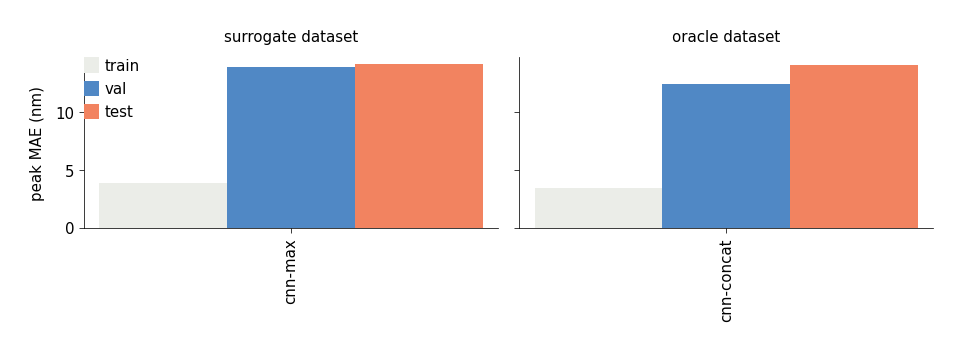

In [5]:
import shutil
# Chosen models (fixed assignment from §3-4): surrogate = cnn-max, oracle = cnn-concat
surr_pick=next(t for t in surr_table if t[0]["sid"]==SURR_SID)
orac_pick=next(t for t in orac_table if t[0]["sid"]==ORAC_SID)
shutil.copy(surr_pick[2], os.path.join("trained_models","dual_surrogate_net.pt"))
shutil.copy(orac_pick[2], os.path.join("trained_models","dual_oracle_net.pt"))
np.savez(os.path.join("trained_models","dual_surrogate_scaler.npz"), mean=surr_scaler[0], std=surr_scaler[1])
np.savez(os.path.join("trained_models","dual_oracle_scaler.npz"),    mean=orac_scaler[0], std=orac_scaler[1])
print(f"surrogate (dataset 1) <- {surr_pick[0]['sid']} | val MAE {surr_pick[1]['val']['mae']:.1f} nm")
print(f"oracle    (dataset 2) <- {orac_pick[0]['sid']} | val MAE {orac_pick[1]['val']['mae']:.1f} nm")
if HAVE_PLT:
    fig,ax=plt.subplots(1,2,figsize=(13,4.5),sharey=True)
    for col,(name,tbl) in enumerate([("surrogate dataset",surr_table),("oracle dataset",orac_table)]):
        sids=[s["sid"] for s,_,_ in tbl]; x=np.arange(len(sids)); w=0.27; a=ax[col]
        tr=[m["train"]["mae"] for _,m,_ in tbl]; vv=[m["val"]["mae"] for _,m,_ in tbl]; tt=[m["test"]["mae"] for _,m,_ in tbl]
        a.bar(x-w,tr,w,color=apc_c.gray,label="train"); a.bar(x,vv,w,color=apc_c.aegean,label="val"); a.bar(x+w,tt,w,color=apc_c.amber,label="test")
        a.set_xticks(x); a.set_xticklabels(sids,rotation=90); a.set_title(name)
        if col==0: a.set_ylabel("peak MAE (nm)")
    ax[0].legend(); plt.tight_layout(); plt.show()

## 6. Parity scatter — predicted vs true peak (top-4, train vs val)

Predicted vs true ex_max (top) and em_max (bottom) for the 4 best surrogate-dataset models; train=blue, val=amber, dashed y=x.

surrogate parity: ['cnn-max S_val MAE 14.0nm']


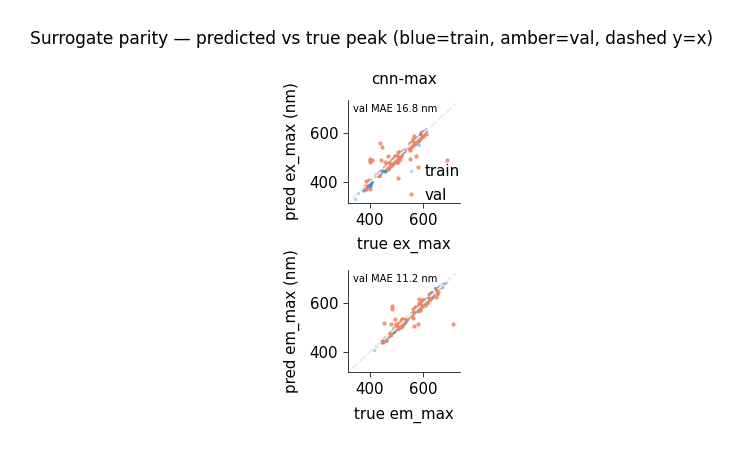

In [6]:
picks=sorted(surr_table, key=lambda t: t[1]["val"]["mae"])
print("surrogate parity:", [f"{t[0]['sid']} S_val MAE {t[1]['val']['mae']:.1f}nm" for t in picks])
if HAVE_PLT:
    lo=float(min(EXM.min(),EMM.min()))-10; hi=float(max(EXM.max(),EMM.max()))+10
    fig,axes=plt.subplots(2,len(picks),figsize=(2.9*max(len(picks),1),5.8),sharex='row',sharey='row',squeeze=False)
    for c,(spec,met,path) in enumerate(picks):
        net,_=load_wrapped(path,*surr_scaler)
        Ptr=predict_peaks(net,SIDX["train"]); Pva=predict_peaks(net,SIDX["val"])
        for row,lab in enumerate(["ex_max","em_max"]):
            a=axes[row,c]; a.plot([lo,hi],[lo,hi],ls="--",color=apc_c.gray)
            a.scatter(peaks[SIDX["train"],row],Ptr[:,row],s=10,color=apc_c.aegean,alpha=0.45,label="train")
            a.scatter(peaks[SIDX["val"],row],  Pva[:,row],s=18,color=apc_c.amber, alpha=0.85,label="val")
            mae=float(np.abs(Pva[:,row]-peaks[SIDX["val"],row]).mean())
            a.text(0.04,0.96,f"val MAE {mae:.1f} nm",transform=a.transAxes,va="top",ha="left",fontsize=10,
                   bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="none",alpha=0.8))
            if row==0: a.set_title(spec["sid"])
            if c==0: a.set_ylabel(f"pred {lab} (nm)")
            a.set_xlabel(f"true {lab}")
    axes[0,0].legend(loc="lower right")
    plt.suptitle("Surrogate parity — predicted vs true peak (blue=train, amber=val, dashed y=x)"); plt.tight_layout(); plt.show()

## 7. Oracle by split region (dual labels)

Chosen oracle on three regions: **S_train ∩ O_train** (oracle in-sample), **S_test ∩ O_train**
(=surrogate-test; oracle in-sample, surrogate-OOD — judges OOD designs here), **S_train ∩ O_test**
(=oracle-test; oracle held-out — certifies its accuracy).

oracle = cnn-concat
region                    n    MAE  ex_MAE  em_MAE  R2_ex  R2_em


S_train ∩ O_train       302    3.4     4.0     2.8   0.99   0.99
S_test ∩ O_train        114    3.4     3.7     3.1   0.99   0.99
S_train ∩ O_test        114   14.1    17.7    10.4   0.67   0.81


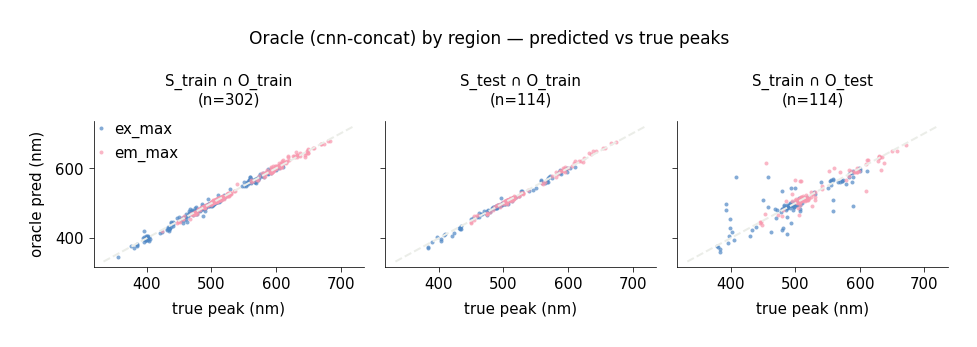

In [7]:
oracle_net,_=load_wrapped(orac_pick[2], *orac_scaler)
groups=[("S_train ∩ O_train", np.intersect1d(SIDX["train"],OIDX["train"])),
        ("S_test ∩ O_train",  np.intersect1d(SIDX["test"], OIDX["train"])),
        ("S_train ∩ O_test",  np.intersect1d(SIDX["train"],OIDX["test"]))]
print(f"oracle = {orac_pick[0]['sid']}")
print(f"{'region':22s} {'n':>4} {'MAE':>6} {'ex_MAE':>7} {'em_MAE':>7} {'R2_ex':>6} {'R2_em':>6}")
for name,idx in groups:
    m=evaluate(oracle_net, idx)
    print(f"{name:22s} {len(idx):>4} {m['mae']:6.1f} {m['ex_mae']:7.1f} {m['em_mae']:7.1f} {m['r2_ex']:6.2f} {m['r2_em']:6.2f}")
if HAVE_PLT:
    lo=float(min(EXM.min(),EMM.min()))-10; hi=float(max(EXM.max(),EMM.max()))+10
    fig,axes=plt.subplots(1,len(groups),figsize=(4.4*len(groups),4.3),sharex=True,sharey=True)
    for c,(name,idx) in enumerate(groups):
        P=predict_peaks(oracle_net,idx); a=axes[c]; a.plot([lo,hi],[lo,hi],ls="--",color=apc_c.gray)
        a.scatter(peaks[idx,0],P[:,0],s=16,color=apc_c.aegean,alpha=0.7,label="ex_max")
        a.scatter(peaks[idx,1],P[:,1],s=16,color=apc_c.rose,  alpha=0.7,label="em_max")
        a.set_title(f"{name}\n(n={len(idx)})"); a.set_xlabel("true peak (nm)")
        if c==0: a.set_ylabel("oracle pred (nm)")
    axes[0].legend()
    plt.suptitle(f"Oracle ({orac_pick[0]['sid']}) by region — predicted vs true peaks"); plt.tight_layout(); plt.show()

## 8. Robust reporting — median peak MAE + bootstrap 95% CI

Mean MAE / R² are dominated by a few **sequence-novel, mechanistically-exotic** FPs (e.g. biliverdin-binding
phytochromes, fluorogen-activating tags, UV proteins) that have no near-neighbor in training; with only ~134
test samples and a single split, *which* test set catches these tail cases is luck (it's the main reason the
oracle's test MAE looks worse than the surrogate's even though their **medians** are close). Median peak MAE is
robust to that tail; bootstrap 95% CIs make the draw-uncertainty explicit for both MAE and R².

model / split             n |    median MAE [95% CI] |  mean |          R2 [95% CI]


surrogate cnn / train   530 |   2.8 [ 2.6,  3.2] nm |   3.9 |  0.99 [ 0.99,0.99]
surrogate cnn / val     114 |   5.9 [ 4.9,  6.9] nm |  14.0 |  0.68 [ 0.47,0.86]


surrogate cnn / test    114 |   6.5 [ 5.3,  7.7] nm |  14.2 |  0.72 [ 0.53,0.86]


oracle cnn / train      530 |   2.6 [ 2.4,  3.0] nm |   3.4 |  0.99 [ 0.99,0.99]
oracle cnn / val        114 |   6.3 [ 4.3,  8.4] nm |  12.4 |  0.83 [ 0.72,0.91]


oracle cnn / test       114 |   6.8 [ 5.5,  7.5] nm |  14.1 |  0.74 [ 0.52,0.88]


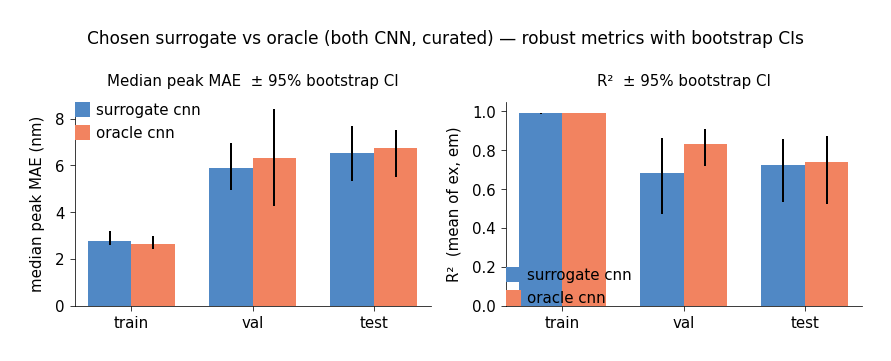

In [8]:
def _abs_err(net, idx):
    P=predict_peaks(net, idx); T=peaks[idx]
    return 0.5*(np.abs(P[:,0]-T[:,0])+np.abs(P[:,1]-T[:,1])), P, T
def boot_med(e, B=3000, seed=0):                                   # median + 95% CI by resampling samples
    r=np.random.default_rng(seed); bs=np.median(e[r.integers(0,len(e),(B,len(e)))],axis=1)
    return float(np.median(e)), float(np.percentile(bs,2.5)), float(np.percentile(bs,97.5))
def _r2c(t,p):
    ss=((t-t.mean())**2).sum(); return 1-((t-p)**2).sum()/ss if ss>0 else float("nan")
def boot_r2(T,P,B=3000,seed=0):
    r=np.random.default_rng(seed); n=len(T); ix=r.integers(0,n,(B,n))
    base=0.5*(_r2c(T[:,0],P[:,0])+_r2c(T[:,1],P[:,1]))
    bs=np.array([0.5*(_r2c(T[i,0],P[i,0])+_r2c(T[i,1],P[i,1])) for i in ix])
    return float(base), float(np.nanpercentile(bs,2.5)), float(np.nanpercentile(bs,97.5))

surr_net,_=load_wrapped(surr_pick[2], *surr_scaler); orac_net,_=load_wrapped(orac_pick[2], *orac_scaler)
groups=["train","val","test"]; summ={}
print(f"{'model / split':22s} {'n':>4} | {'median MAE [95% CI]':>22} | {'mean':>5} | {'R2 [95% CI]':>20}")
for tag,net,IDX in [("surrogate cnn", surr_net, SIDX), ("oracle cnn", orac_net, OIDX)]:
    for s in groups:
        e,P,T=_abs_err(net, IDX[s]); med,lo,hi=boot_med(e); r2,rlo,rhi=boot_r2(T,P)
        summ[(tag,s)]=(med,lo,hi,float(e.mean()),r2,rlo,rhi)
        print(f"{tag+' / '+s:22s} {len(e):>4} | {med:5.1f} [{lo:4.1f},{hi:5.1f}] nm | {e.mean():5.1f} | {r2:5.2f} [{rlo:5.2f},{rhi:4.2f}]")

if HAVE_PLT:
    x=np.arange(3); w=0.36
    fig,ax=plt.subplots(1,2,figsize=(12,4.5))
    for k,(tag,col) in enumerate([("surrogate cnn",apc_c.aegean),("oracle cnn",apc_c.amber)]):
        med=[summ[(tag,s)][0] for s in groups]
        elo=[summ[(tag,s)][0]-summ[(tag,s)][1] for s in groups]; ehi=[summ[(tag,s)][2]-summ[(tag,s)][0] for s in groups]
        ax[0].bar(x+(k-0.5)*w, med, w, yerr=[elo,ehi], capsize=4, color=col, label=tag)
        r2=[summ[(tag,s)][4] for s in groups]
        rlo=[summ[(tag,s)][4]-summ[(tag,s)][5] for s in groups]; rhi=[summ[(tag,s)][6]-summ[(tag,s)][4] for s in groups]
        ax[1].bar(x+(k-0.5)*w, r2, w, yerr=[rlo,rhi], capsize=4, color=col, label=tag)
    ax[0].set_ylabel("median peak MAE (nm)"); ax[0].set_title("Median peak MAE  ± 95% bootstrap CI")
    ax[1].set_ylabel("R²  (mean of ex, em)"); ax[1].set_title("R²  ± 95% bootstrap CI"); ax[1].set_ylim(0,1.05)
    for a in ax: a.set_xticks(x); a.set_xticklabels(groups); a.legend()
    plt.suptitle("Chosen surrogate vs oracle (both CNN, curated) — robust metrics with bootstrap CIs")
    plt.tight_layout(); fig.savefig("trained_models/test_median_ci_curated.png", dpi=130, bbox_inches="tight"); plt.show()

## Notes
- Trained on the **curated** dataset (`training_data/curated/`, 758 samples); embeddings are subset from the raw
  823-sample cache by `keep_index` (no re-embedding). Targets are the **two peak wavelengths** `(ex_max, em_max)`
  (nm), standardized per dataset on its train split; metrics are MAE / R² **per peak (nm)**.
- Backbones: **CNN only**, `mean/min/max/concat` masked pooling over ESM-2 embeddings (4 readout options defined; only the assigned one is trained per dataset).
- Chosen models use a **fixed assignment**: **surrogate = cnn-max**, **oracle = cnn-concat** (only the assigned
  readout is trained per dataset; no readout search). The oracle's independence comes from its disjoint
  training split. Cache key includes `peaks` + a dual-split signature, so these checkpoints don't collide with
  the earlier raw / curated-829 ones (now archived under `trained_models/archive/`).
- `curated/dual_splits.csv` labels each FP with surrogate/oracle roles for in-sample vs OOD design evaluation.